<h1>Wine database study</h1>

<h2>Gabriele Cerioli, BsC Physics UNITS, Internship ICTP</h2>

<img src="https://www.coravin.it/cdn/shop/articles/AdobeStock_791180394_549e319b-e031-4757-84c1-9796e2192a3d.jpg?v=1750068247" alt="Italian Trulli">

<h2>01) The database</h2>

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
Y = wine_quality.data.targets  

In [3]:
import numpy as np
import pandas as pd

print(X.shape)
print(Y.shape)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xs = scaler.fit_transform(X)  # Standardise the components

(6497, 11)
(6497, 1)


<Axes: >

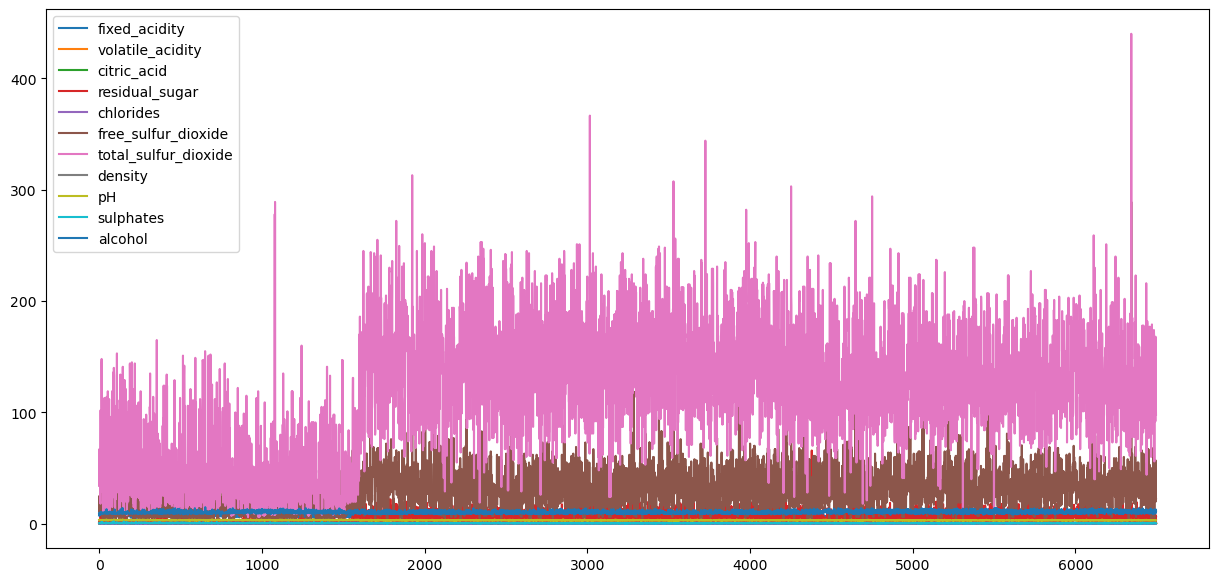

In [4]:
X.plot(figsize=(15,7))

<h3>Do we need to standardize the features to make them compatible?</h3>

In [ ]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)  # Standardise the components

<h3>Let's check the independence of the 11 proprierties</h3>

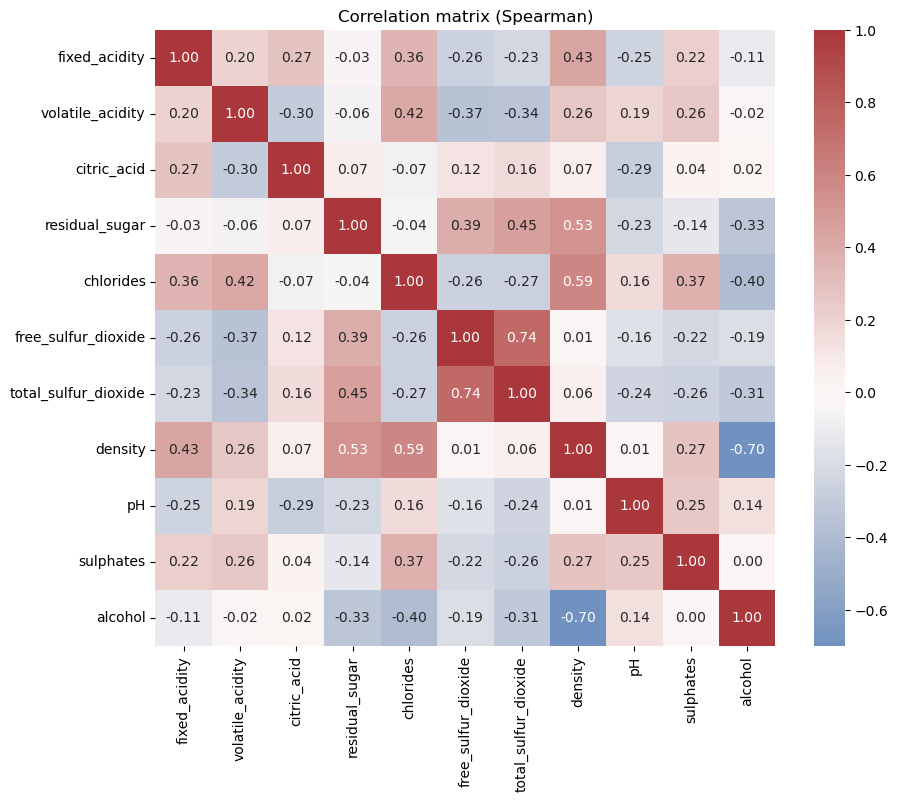

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

corr_spearman = X.corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix (Spearman)")
plt.show()

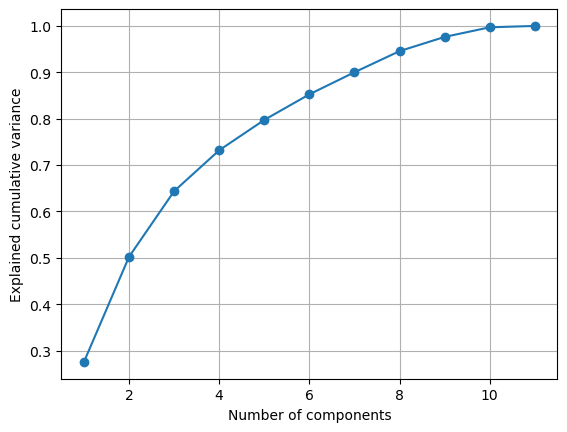

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA()
pca.fit(Xs)
explained = np.cumsum(pca.explained_variance_ratio_)

import matplotlib.pyplot as plt
plt.plot(np.arange(1, len(explained)+1), explained, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Explained cumulative variance')
plt.grid(True)
plt.show()


<h3>Maybe can we combine some redundant features?</h3>

<h3>Let's calcolate how much each feature weight on the quality score</h3>

In [7]:
wine_quality_united= pd.concat([X, Y], axis=1)

In [8]:
corr = wine_quality_united.corr(method='spearman')["quality"].sort_values(ascending=False)
print("Importance with correlation:")
print(corr)

Importance with correlation:
quality                 1.000000
alcohol                 0.446925
citric_acid             0.105711
free_sulfur_dioxide     0.086865
pH                      0.032538
sulphates               0.029831
residual_sugar         -0.016891
total_sulfur_dioxide   -0.054777
fixed_acidity          -0.098154
volatile_acidity       -0.257806
chlorides              -0.295054
density                -0.322806
Name: quality, dtype: float64


In [9]:
Y = Y.values.ravel() 

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


# standardizza per rendere comparabili i coefficienti
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
model = LinearRegression()
model.fit(Xs, Y)

importances =pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print("Importances with linear regression:")
print(importances)


Importances with linear regression:
alcohol                 0.318465
residual_sugar          0.207228
sulphates               0.114312
free_sulfur_dioxide     0.105954
fixed_acidity           0.087741
pH                      0.070628
citric_acid            -0.015934
chlorides              -0.016945
total_sulfur_dioxide   -0.140237
density                -0.164815
volatile_acidity       -0.218603
dtype: float64


<H3>We need to define a new metric rather than the purity score!</H3>

If our clustering algorithm assign to a wine a quality score of 6 and the ground thruth is 7, it should be considered better than assigning a score of 3 to the same wine

But labeling the point to the cluster 4 doesn't mean the quality score is 4. The clustering labels are arbitrary

So we need for example to associate to each cluster the corrisponding mean,median or mode quality value.

In [11]:
def metric_score(labels,ground_truth):
    import pandas as pd
    import numpy as np
    
    df_eval = pd.DataFrame({'cluster': labels, 'quality': ground_truth})
    
    # representative per cluster (median, mean, or mode)
    cluster_quality = df_eval.groupby('cluster')['quality'].mean()  # or .mean()
    
    print("Cluster quality: ", cluster_quality)
    return()


<h2>Clustering of the data</h2>

In [12]:
from sklearn.cluster import KMeans
x = X.to_numpy()   # oppure: x.values
data_matrix=x
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_


<h3>PCA decomposition</h3>

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

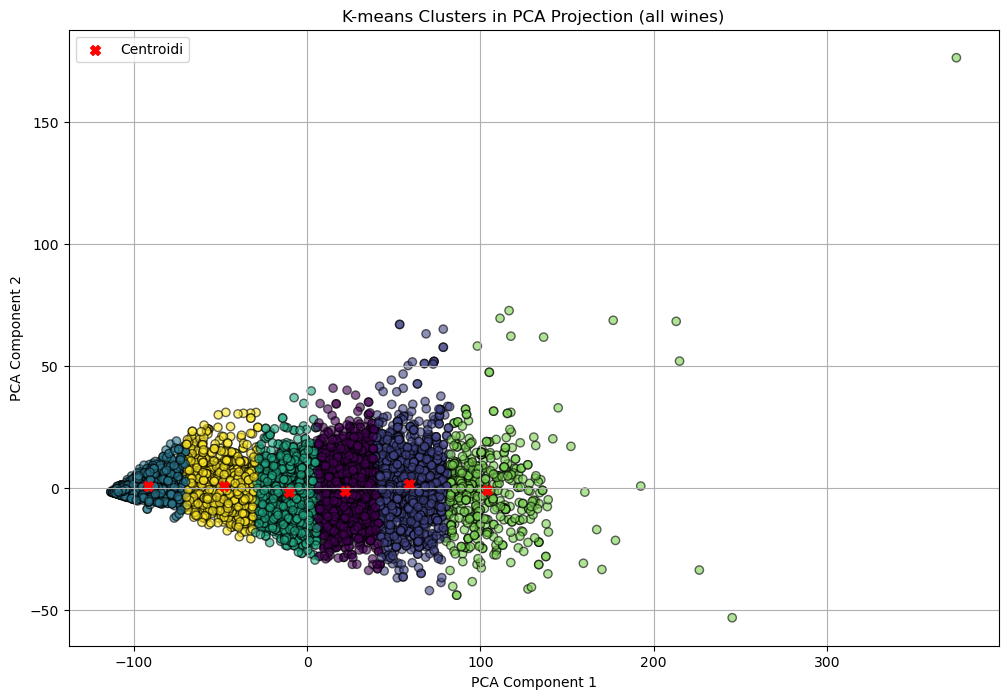

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=cluster_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters in PCA Projection (all wines)")
plt.legend()
plt.grid(True)
plt.savefig("K-means Clusters in PCA Projection (all wines).pdf", format="pdf")
plt.show()


In [17]:
ground_truth=Y
metric_score(cluster_assignments,ground_truth.flatten())

Cluster quality:  cluster
0    5.962105
1    5.703004
2    5.727096
3    6.011243
4    5.488889
5    5.697941
Name: quality, dtype: float64


()

<h2>Gaussian Mixtures </h2>

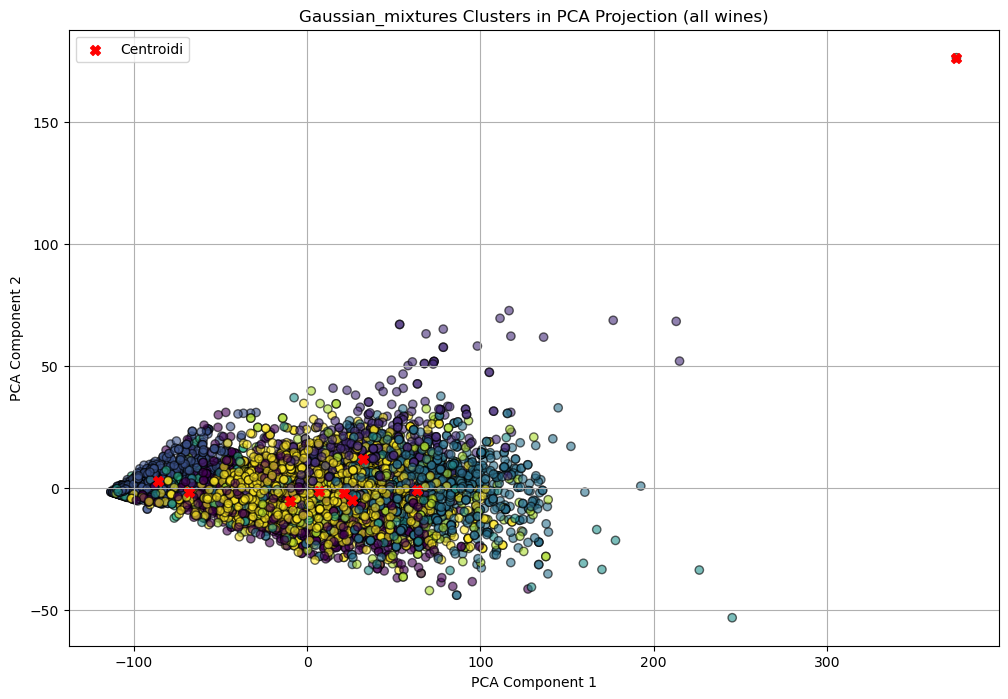

In [18]:
from sklearn.mixture import GaussianMixture
n_clusters = 9

gmm = GaussianMixture(n_components=n_clusters)

gmm.fit(data_matrix)

soft_assignments = gmm.predict_proba(data_matrix)

hard_assignments = gmm.predict(data_matrix)

centroids = gmm.means_

#PCA and plotting:

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=hard_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian_mixtures Clusters in PCA Projection (all wines)")
plt.legend()
plt.grid(True)
plt.savefig("Gaussian_mixtures Clusters in PCA Projection (all wines).pdf", format="pdf")

plt.show()

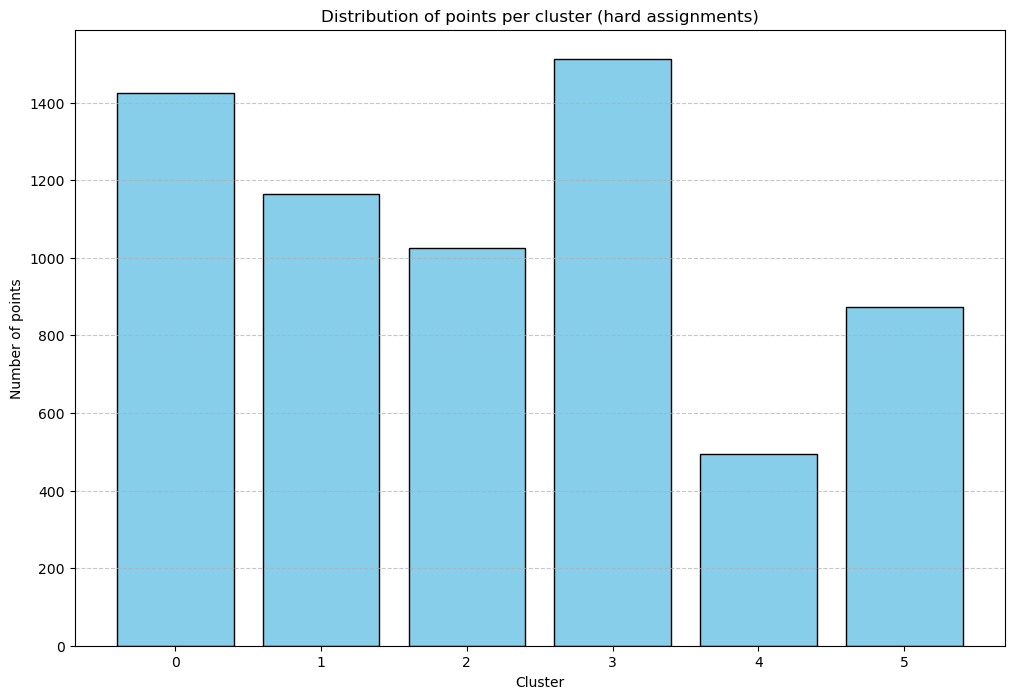

In [19]:
unique_clusters, counts = np.unique(cluster_assignments, return_counts=True)

plt.figure(figsize=(12,8))
plt.bar(unique_clusters, counts, color="skyblue", edgecolor="black")
plt.xlabel("Cluster")
plt.ylabel("Number of points")
plt.title("Distribution of points per cluster (hard assignments)")
plt.xticks(unique_clusters)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("Distribution of points per cluster (hard assignments).pdf", format="pdf")

plt.show()


In [20]:
metric_score(hard_assignments,ground_truth.flatten())

Cluster quality:  cluster
0    5.523629
1    5.927393
2    5.757000
3    5.520976
4    5.687117
5    5.665306
6    3.000000
7    5.262821
8    6.224245
Name: quality, dtype: float64


()

<h2>What if we divide red and white wines?</h2>

<h2>Red wines</h2>

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("winequality-red.csv", sep=";")
print(df.columns.tolist())

# Seleziona le colonne che ti interessano
selected_columns = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates","alcohol"]

# Crea la matrice NumPy
data_matrix = df[selected_columns].to_numpy()
quality_selected_column=["quality"]
ground_truth=df[quality_selected_column].to_numpy()
print("Shape della matrice:", data_matrix.shape)
print(data_matrix)


['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Shape della matrice: (1599, 11)
[[ 7.4    0.7    0.    ...  3.51   0.56   9.4  ]
 [ 7.8    0.88   0.    ...  3.2    0.68   9.8  ]
 [ 7.8    0.76   0.04  ...  3.26   0.65   9.8  ]
 ...
 [ 6.3    0.51   0.13  ...  3.42   0.75  11.   ]
 [ 5.9    0.645  0.12  ...  3.57   0.71  10.2  ]
 [ 6.     0.31   0.47  ...  3.39   0.66  11.   ]]


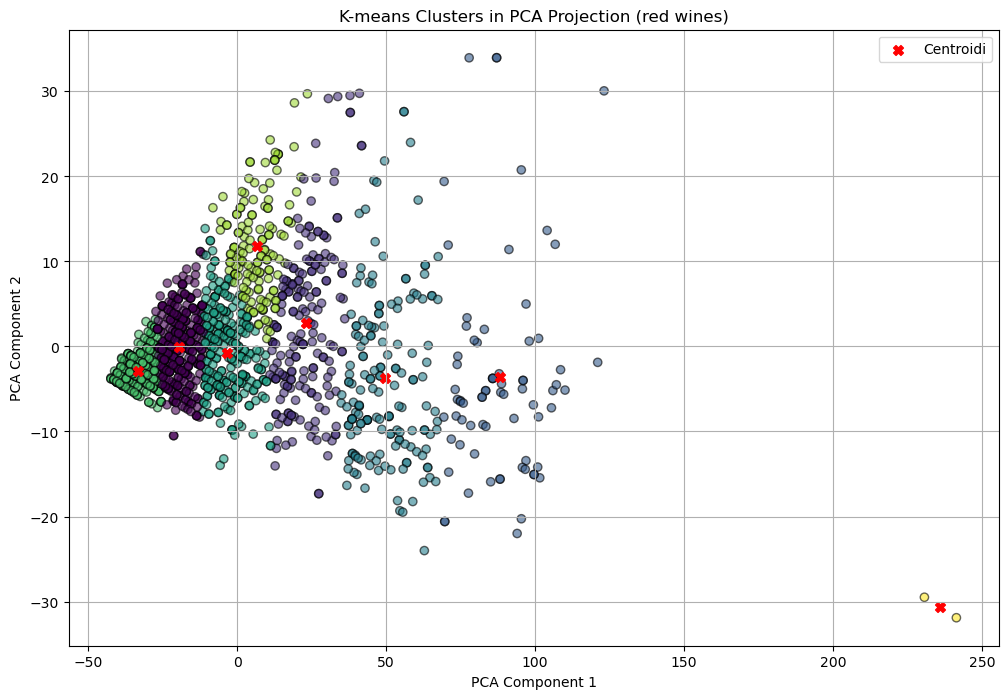

Cluster quality:  cluster
0    5.742627
1    5.505102
2    5.068493
3    5.387879
4    5.644444
5    5.759358
6    5.753425
7    7.000000
Name: quality, dtype: float64


()

In [22]:

n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=cluster_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters in PCA Projection (red wines)")
plt.legend()
plt.grid(True)
plt.savefig("K-means Clusters in PCA Projection (red wines).pdf", format="pdf")

plt.show()

metric_score(cluster_assignments,ground_truth.flatten())

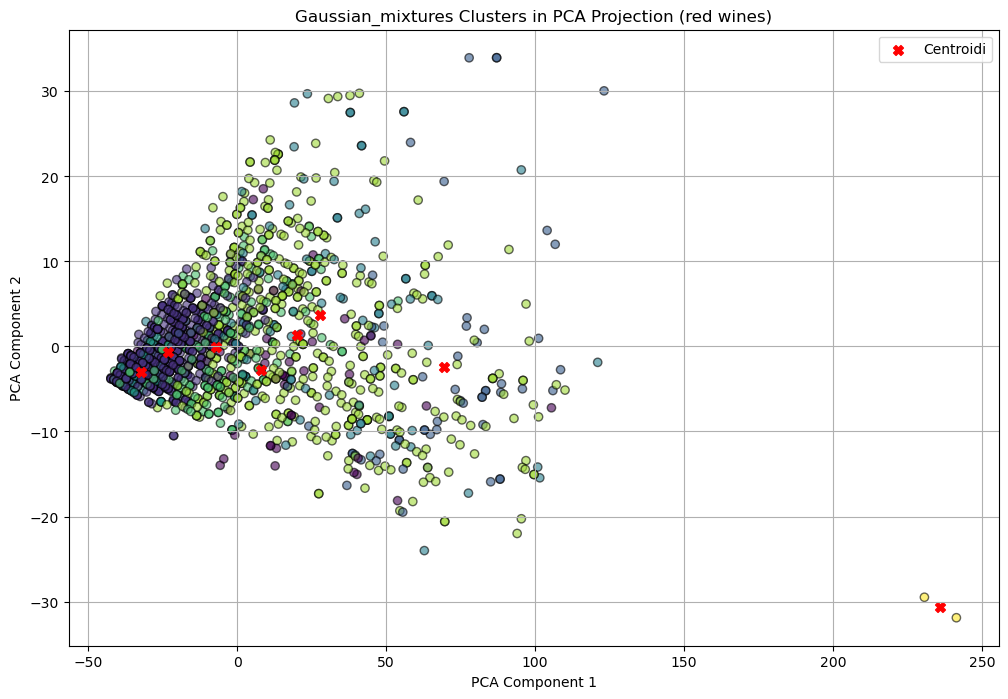

Cluster quality:  cluster
0    5.246154
1    5.811321
2    5.090909
3    5.833333
4    5.841121
5    5.703349
6    5.408511
7    7.000000
Name: quality, dtype: float64


()

In [23]:
n_clusters = 8

gmm = GaussianMixture(n_components=n_clusters)

gmm.fit(data_matrix)

soft_assignments = gmm.predict_proba(data_matrix)

hard_assignments = gmm.predict(data_matrix)

centroids = gmm.means_

#PCA and plotting:

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=hard_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian_mixtures Clusters in PCA Projection (red wines)")
plt.legend()
plt.grid(True)
plt.savefig("Gaussian_mixtures Clusters in PCA Projection (red wines).pdf", format="pdf")

plt.show()

metric_score(hard_assignments,ground_truth.flatten())

<h2>White wines</h2>

In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("winequality-white.csv", sep=";")
print(df.columns.tolist())

# Seleziona le colonne che ti interessano
selected_columns = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates","alcohol"]

# Crea la matrice NumPy
data_matrix = df[selected_columns].to_numpy()
quality_selected_column=["quality"]
ground_truth=df[quality_selected_column].to_numpy()
print("Shape della matrice:", data_matrix.shape)
print(data_matrix)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Shape della matrice: (4898, 11)
[[ 7.    0.27  0.36 ...  3.    0.45  8.8 ]
 [ 6.3   0.3   0.34 ...  3.3   0.49  9.5 ]
 [ 8.1   0.28  0.4  ...  3.26  0.44 10.1 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]


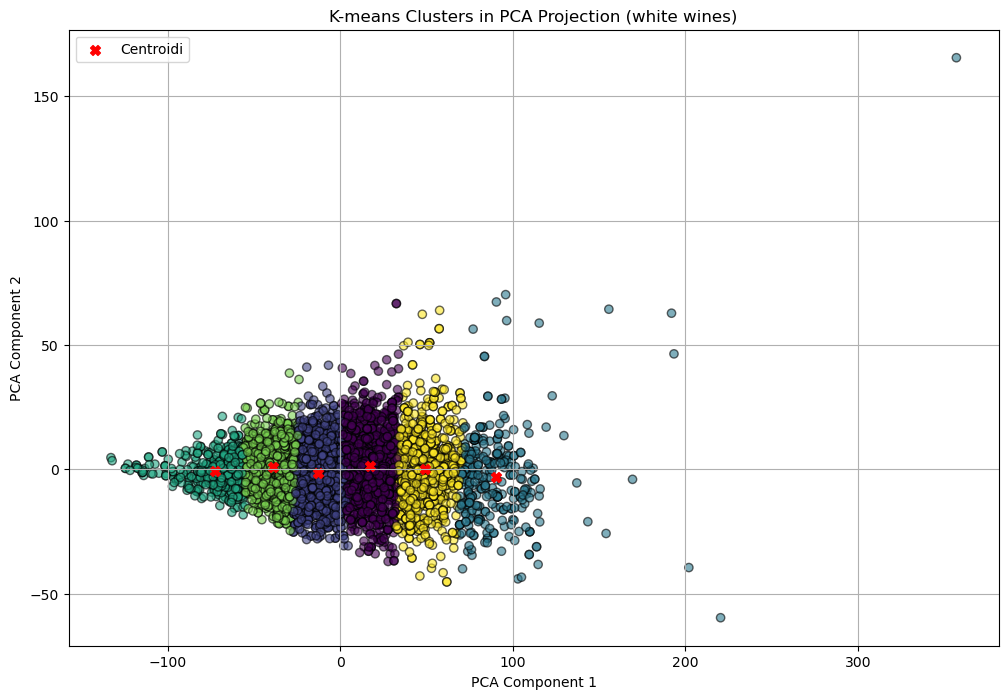

Cluster quality:  cluster
0    5.873742
1    6.032841
2    5.517350
3    5.749409
4    6.098470
5    5.570537
Name: quality, dtype: float64


()

In [25]:
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=cluster_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters in PCA Projection (white wines)")
plt.legend()
plt.grid(True)
plt.savefig("K-means Clusters in PCA Projection (white wines).pdf", format="pdf")

plt.show()

metric_score(cluster_assignments,ground_truth.flatten())

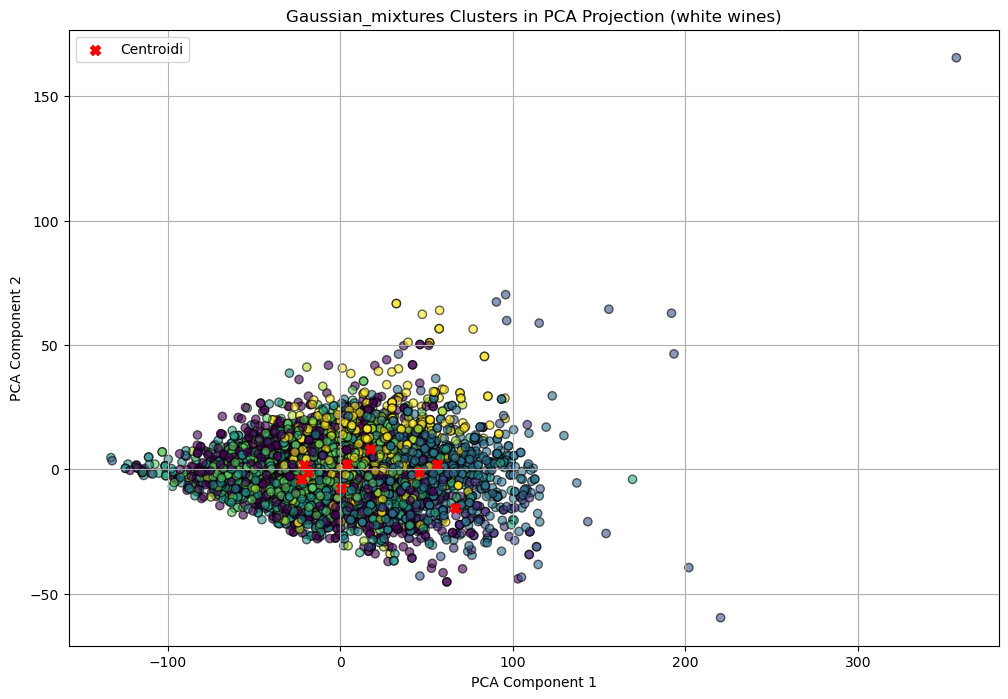

Cluster quality:  cluster
0    5.949924
1    5.304878
2    5.077922
3    5.550122
4    5.856899
5    5.622881
6    6.326065
7    5.535484
8    5.805195
Name: quality, dtype: float64


()

In [26]:
n_clusters = 9

gmm = GaussianMixture(n_components=n_clusters)

gmm.fit(data_matrix)

soft_assignments = gmm.predict_proba(data_matrix)

hard_assignments = gmm.predict(data_matrix)

centroids = gmm.means_

#PCA and plotting:

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=hard_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian_mixtures Clusters in PCA Projection (white wines)")
plt.legend()
plt.grid(True)
plt.savefig("Gaussian_mixtures Clusters in PCA Projection (white wines).pdf", format="pdf")

plt.show()

metric_score(hard_assignments,ground_truth.flatten())

<h1>What if we apply supervised learning?</h1>